In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [146]:
df=pd.read_csv('titanic_large.csv')

In [127]:
df.head(-10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
403,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.0,0,0,113059,47.1000,NaN,S
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.0,1,0,17765,27.7208,D40,C
405,1297,0,2,"Nourney, Mr. Alfred (Baron von Drachstedt"")""",male,20.0,0,0,SC/PARIS 2166,13.8625,D38,C
406,1298,0,2,"Ware, Mr. William Jeffery",male,23.0,1,0,28666,10.5000,NaN,S


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   PassengerId  100000 non-null  int64  
 1   Survived     100000 non-null  int64  
 2   Pclass       100000 non-null  int64  
 3   Name         100000 non-null  object 
 4   Sex          100000 non-null  object 
 5   Age          80144 non-null   float64
 6   SibSp        100000 non-null  int64  
 7   Parch        100000 non-null  int64  
 8   Ticket       100000 non-null  int64  
 9   Fare         100000 non-null  float64
 10  Embarked     100000 non-null  object 
dtypes: float64(2), int64(6), object(3)
memory usage: 8.4+ MB


In [18]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


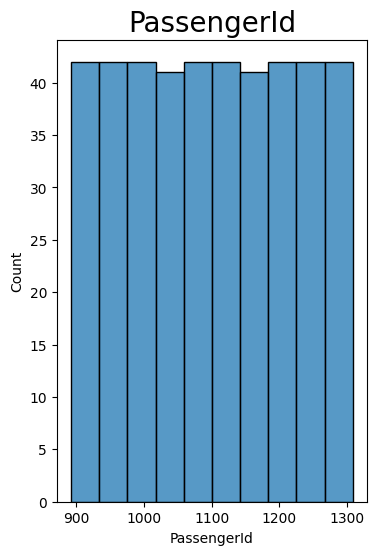

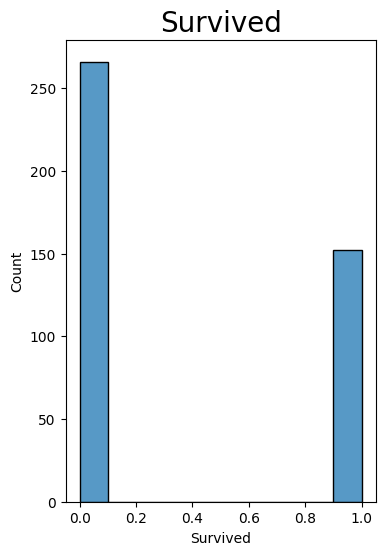

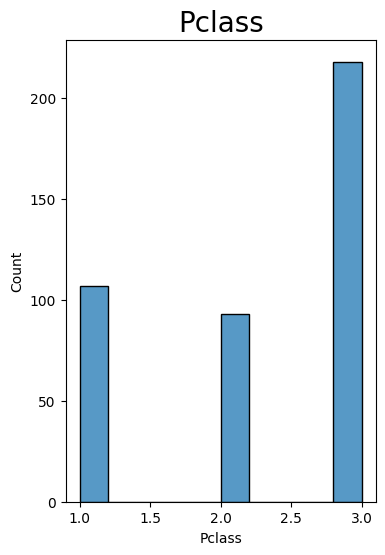

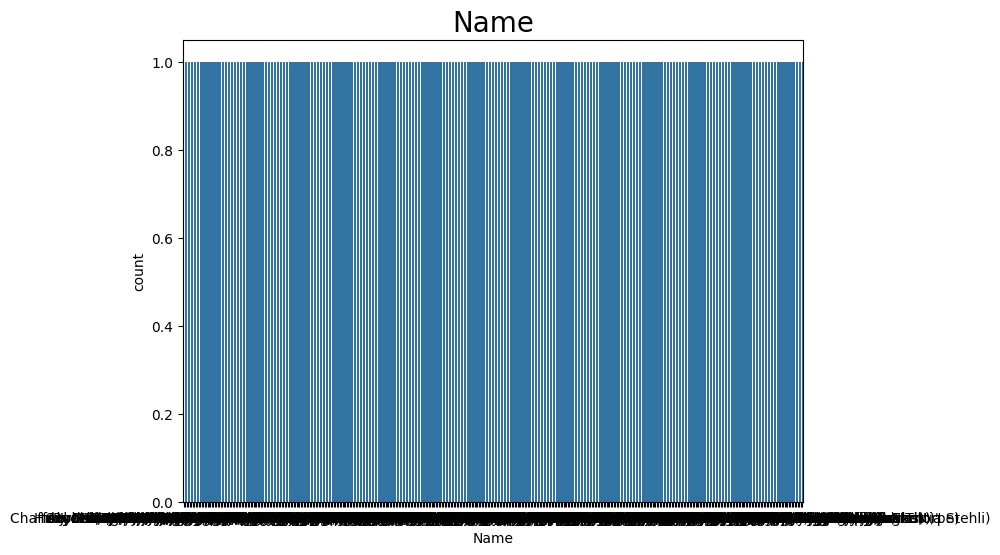

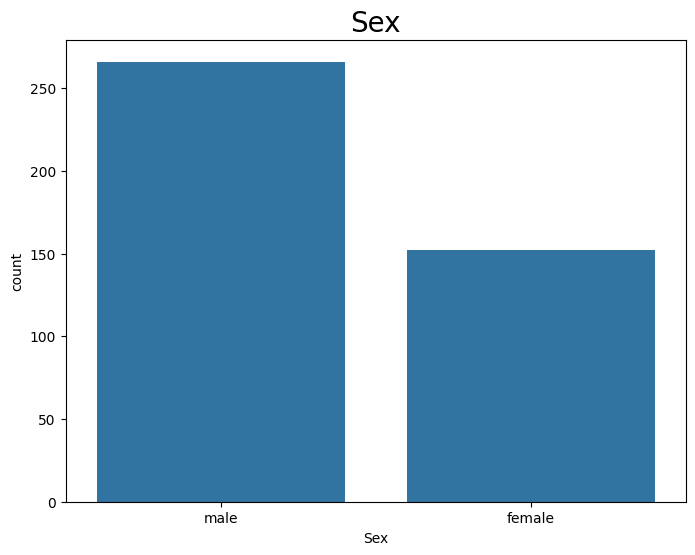

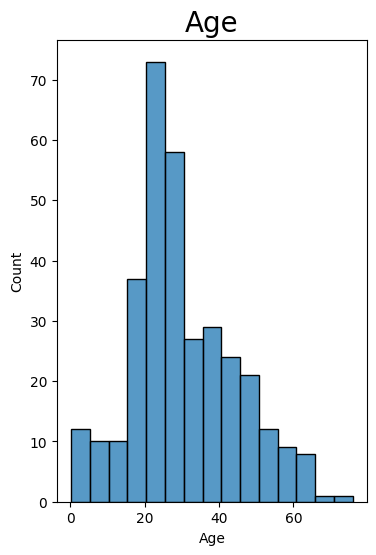

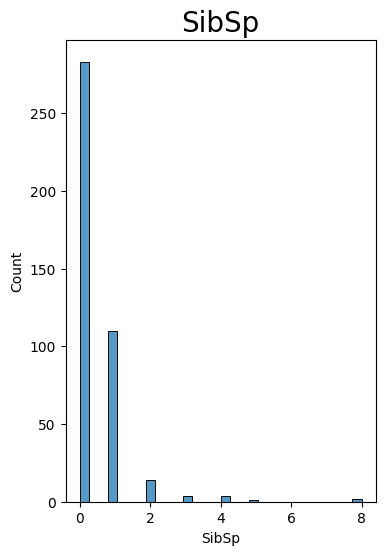

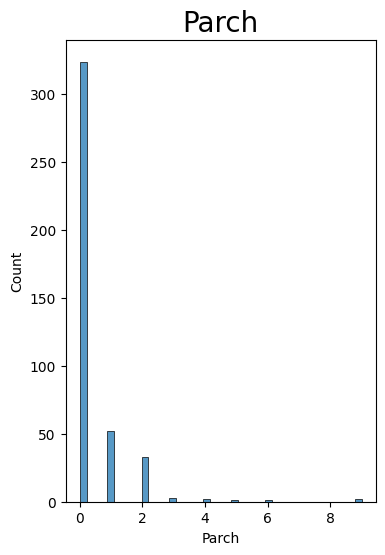

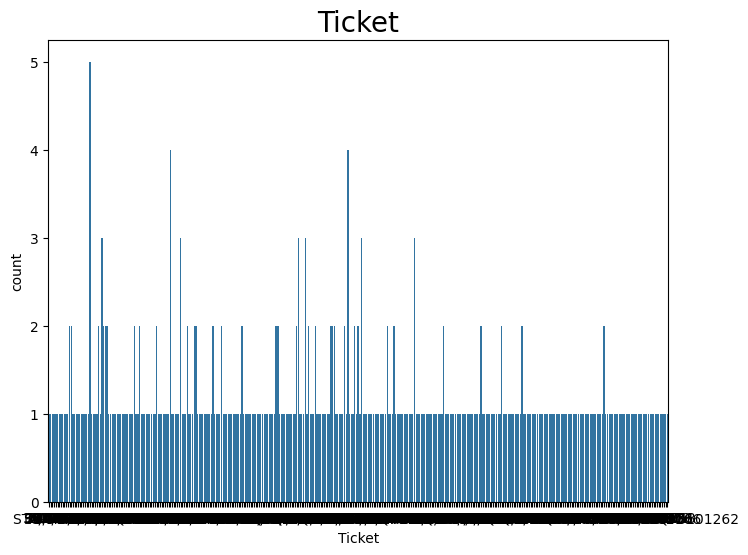

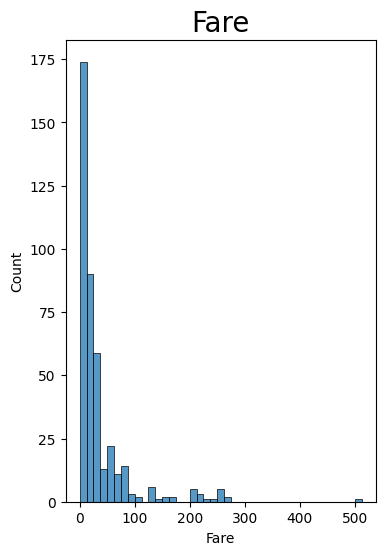

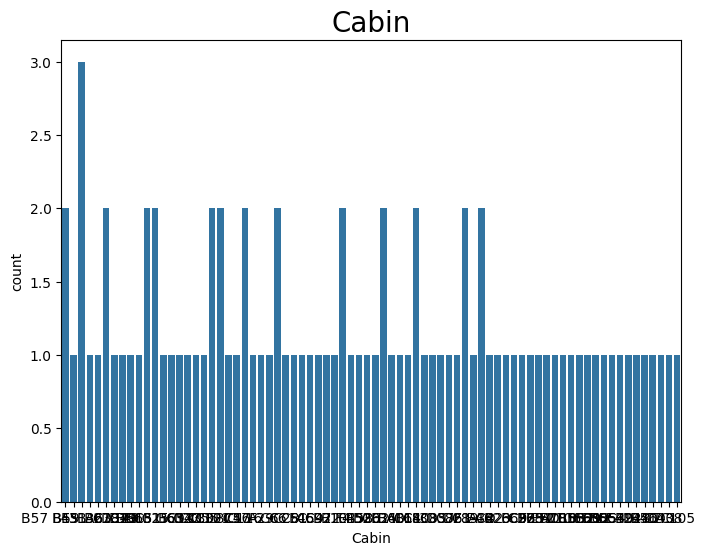

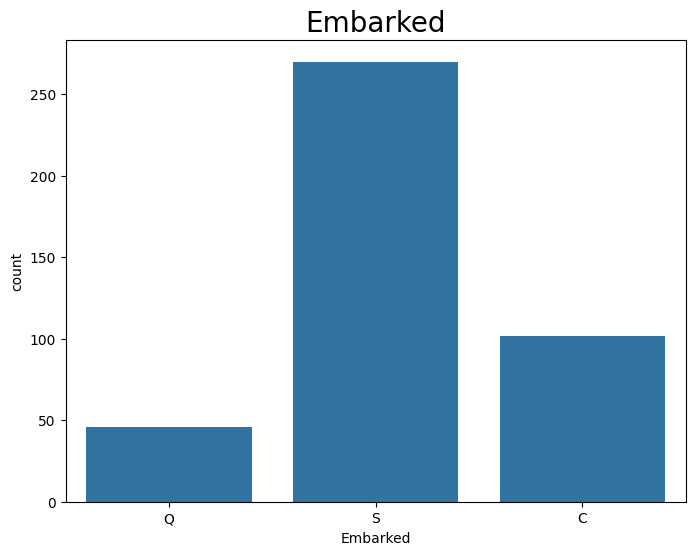

In [25]:
for col in df.columns:
    if df[col].dtype=='object':
        plt.figure(figsize=(8,6))
        sns.countplot(data=df,x=col)
        plt.title(col,fontsize=20)
        plt.show()
    else:
        plt.figure(figsize=(4,6))
        sns.histplot(data=df,x=col)
        plt.title(col,fontsize=20)
        plt.show()

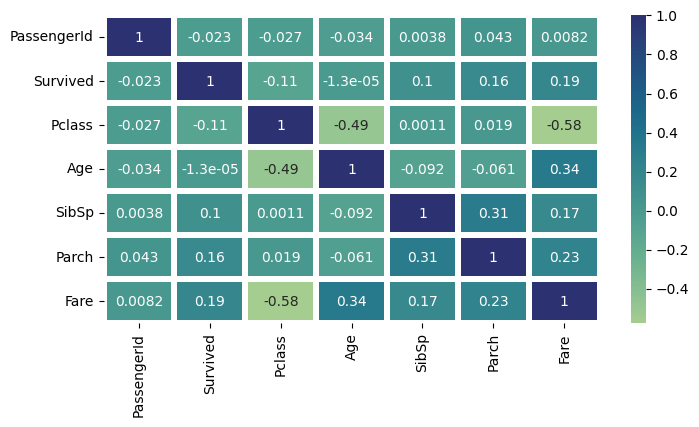

In [32]:
plt.figure(figsize=(8,4))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='crest',lw=3)
plt.show()

In [156]:
df.head(-1)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,75722,0,3,"Robinson, Master. Steven",male,55.6,2,3,600542,3.02,Q
1,80185,1,2,"Wilson, Master. Richard",male,85.0,1,0,561216,8.68,S
2,19865,1,2,"Taylor, Ms. Betty",female,NaN,0,0,589751,4.61,S
3,76700,1,3,"Smith, Mrs. Elizabeth",female,13.3,0,0,96366,5.56,S
4,92992,0,1,"Jackson, Rev. Daniel",male,55.9,0,1,416388,40.64,S
...,...,...,...,...,...,...,...,...,...,...,...
99994,82387,1,1,"Robinson, Ms. Mary",female,38.1,0,1,481773,25.52,S
99995,6266,0,3,"Robinson, Rev. James",male,32.0,1,1,219100,2.53,S
99996,54887,0,3,"Jackson, Mr. Donald",male,25.5,0,0,403270,17.17,S
99997,76821,0,2,"Wilson, Rev. Donald",male,NaN,1,0,345632,12.25,S


In [157]:
df['Parch'].unique()

array([3, 0, 1, 2, 4, 5, 6])

In [165]:
ordinal_features=['Pclass']
numerical_features=['Age','SibSp','Parch','Fare']
nominal_features=['Embarked','Sex']

In [166]:
ordinal_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal_emcoder',OrdinalEncoder())
])


numerical_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('standardscale',StandardScaler())
])


nominal_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
     ('onehotencoding',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))
])

In [167]:
preprocessor=ColumnTransformer(transformers=[
    ('num',numerical_pipeline,numerical_features),
    ('ordinal',ordinal_pipeline,ordinal_features),
    ('nominal',nominal_pipeline,nominal_features)
])

In [148]:
y=df.Survived

In [168]:
x=df[numerical_features+nominal_features+ordinal_features]

In [169]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=.8,random_state=42)

In [170]:
model_pipeline=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [171]:
model_pipeline.fit(x_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('ordinal', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [172]:
predict_y=model_pipeline.predict(x_test)

In [173]:
print(f'accuracy score:{accuracy_score(y_test,predict_y)}')

accuracy score:0.65545


In [174]:
y1=model_pipeline.predict(x_train)

In [175]:
accuracy_score(y_train,y1)

0.6548875

In [176]:
from sklearn.metrics import f1_score

In [177]:
f1_score(y_test,predict_y)

0.4715085512692691